# Inspect Expected Scores

Use this notebook to inspect `data/rugby_league_pricing.db`.

It includes:
- schema and row counts;
- summary statistics;
- distributions;
- extreme fixtures;
- team-level averages;
- expected versus actual scores.


In [1]:
from pathlib import Path
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find pyproject.toml.")

PROJECT_ROOT = find_project_root()
DATABASE_PATH = PROJECT_ROOT / "data" / "rugby_league_pricing.db"

if not DATABASE_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DATABASE_PATH}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Database: {DATABASE_PATH}")


Project root: /workspaces/rugby_league_pricing
Database: /workspaces/rugby_league_pricing/data/rugby_league_pricing.db


## Inspect tables and schema

In [3]:
with sqlite3.connect(DATABASE_PATH) as connection:
    tables = pd.read_sql_query(
        "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name",
        connection,
    )
    schema = pd.read_sql_query("PRAGMA table_info(expected_scores)", connection)

display(tables)
display(schema)


,name
0,expected_scores
1,fixtures
2,historical_score_matrices
3,recent_form
4,results
5,sqlite_sequence
6,strength_multipliers
7,team_source_mappings
8,teams


,cid,name,type,notnull,dflt_value,pk
0,0,expected_score_id,INTEGER,0,NaN,1
1,1,fixture_id,TEXT,1,NaN,0
2,2,match_date,TEXT,1,NaN,0
3,3,season,INTEGER,1,NaN,0
4,4,home_team_id,INTEGER,1,NaN,0
5,5,away_team_id,INTEGER,1,NaN,0
6,6,league_average_points,REAL,1,NaN,0
7,7,home_scoring_factor,REAL,1,NaN,0
8,8,away_scoring_factor,REAL,1,NaN,0
9,9,home_attack_multiplier,REAL,1,NaN,0


## Load expected scores

In [4]:
with sqlite3.connect(DATABASE_PATH) as connection:
    expected_scores = pd.read_sql_query("SELECT * FROM expected_scores", connection)

for column in [c for c in expected_scores.columns if "date" in c.lower()]:
    expected_scores[column] = pd.to_datetime(expected_scores[column], errors="coerce")

print(f"Rows: {len(expected_scores):,}")
display(expected_scores.head())


Rows: 3,103


,expected_score_id,fixture_id,match_date,season,home_team_id,away_team_id,league_average_points,home_scoring_factor,away_scoring_factor,home_attack_multiplier,home_defence_multiplier,away_attack_multiplier,away_defence_multiplier,expected_home_score,expected_away_score,expected_margin,expected_total,created_at,updated_at
0,1,2010-01-30_17_8,2010-01-30,2010,17,8,20.000,0.300,1.700,1.000,1.000,1.000,1.000,6.000,34.000,-28.000,40.000,2026-07-29 14:44:07,2026-07-29 14:44:07
1,2,2010-02-05_11_14,2010-02-05,2010,11,14,17.000,0.471,1.529,1.000,1.000,1.000,1.000,8.000,26.000,-18.000,34.000,2026-07-29 14:44:07,2026-07-29 14:44:07
2,3,2010-02-05_1_16,2010-02-05,2010,1,16,17.000,0.471,1.529,1.000,1.000,0.837,1.240,9.923,21.750,-11.827,31.673,2026-07-29 14:44:07,2026-07-29 14:44:07
3,4,2010-02-05_7_6,2010-02-05,2010,7,6,17.000,0.471,1.529,1.209,0.831,1.000,1.000,9.676,21.608,-11.932,31.284,2026-07-29 14:44:07,2026-07-29 14:44:07
4,5,2010-02-06_9_4,2010-02-06,2010,9,4,18.200,0.967,1.033,1.000,1.000,1.000,1.000,17.600,18.800,-1.200,36.400,2026-07-29 14:44:07,2026-07-29 14:44:07


In [5]:
def first_existing_column(dataframe: pd.DataFrame, candidates: list[str]) -> str | None:
    return next((column for column in candidates if column in dataframe.columns), None)

HOME_EXPECTED_COLUMN = first_existing_column(
    expected_scores,
    ["expected_home_score", "home_expected_score"],
)
AWAY_EXPECTED_COLUMN = first_existing_column(
    expected_scores,
    ["expected_away_score", "away_expected_score"],
)
FIXTURE_ID_COLUMN = first_existing_column(
    expected_scores,
    ["fixture_id", "match_id"],
)

if HOME_EXPECTED_COLUMN is None or AWAY_EXPECTED_COLUMN is None:
    raise KeyError(
        "Could not detect expected-score columns. "
        f"Available columns: {expected_scores.columns.tolist()}"
    )

print(HOME_EXPECTED_COLUMN, AWAY_EXPECTED_COLUMN, FIXTURE_ID_COLUMN)


expected_home_score expected_away_score fixture_id


## Overall summary

In [6]:
score_columns = [HOME_EXPECTED_COLUMN, AWAY_EXPECTED_COLUMN]

summary = expected_scores[score_columns].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T
summary["missing"] = expected_scores[score_columns].isna().sum()
summary["non_positive"] = (expected_scores[score_columns] <= 0).sum()

display(summary)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max,missing,non_positive
expected_home_score,"3,103.000",25.948,7.527,6.000,12.883,15.580,17.193,20.493,24.983,30.206,36.084,39.700,48.434,63.626,0,0
expected_away_score,"3,103.000",22.343,6.563,7.396,10.340,13.073,14.758,17.819,21.611,25.938,30.735,34.539,41.186,60.802,0,0


In [7]:
inspection = expected_scores.copy()
inspection["expected_total"] = (
    inspection[HOME_EXPECTED_COLUMN] + inspection[AWAY_EXPECTED_COLUMN]
)
inspection["expected_margin"] = (
    inspection[HOME_EXPECTED_COLUMN] - inspection[AWAY_EXPECTED_COLUMN]
)

display(
    inspection[
        [
            HOME_EXPECTED_COLUMN,
            AWAY_EXPECTED_COLUMN,
            "expected_total",
            "expected_margin",
        ]
    ].describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ).T
)


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
expected_home_score,"3,103.000",25.948,7.527,6.000,12.883,15.580,17.193,20.493,24.983,30.206,36.084,39.700,48.434,63.626
expected_away_score,"3,103.000",22.343,6.563,7.396,10.340,13.073,14.758,17.819,21.611,25.938,30.735,34.539,41.186,60.802
expected_total,"3,103.000",48.291,7.088,26.402,33.495,37.473,39.671,43.538,47.932,52.526,57.334,60.720,67.662,84.465
expected_margin,"3,103.000",3.605,12.215,-53.383,-24.632,-16.593,-11.485,-4.072,3.333,11.546,18.788,23.692,34.252,50.431


## Distributions

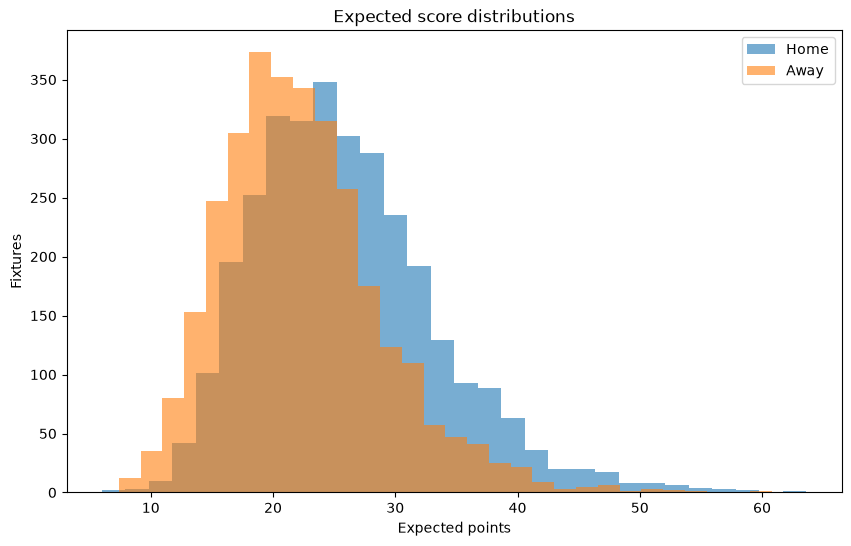

In [8]:
figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(inspection[HOME_EXPECTED_COLUMN].dropna(), bins=30, alpha=0.6, label="Home")
axis.hist(inspection[AWAY_EXPECTED_COLUMN].dropna(), bins=30, alpha=0.6, label="Away")
axis.set_title("Expected score distributions")
axis.set_xlabel("Expected points")
axis.set_ylabel("Fixtures")
axis.legend()
plt.show()


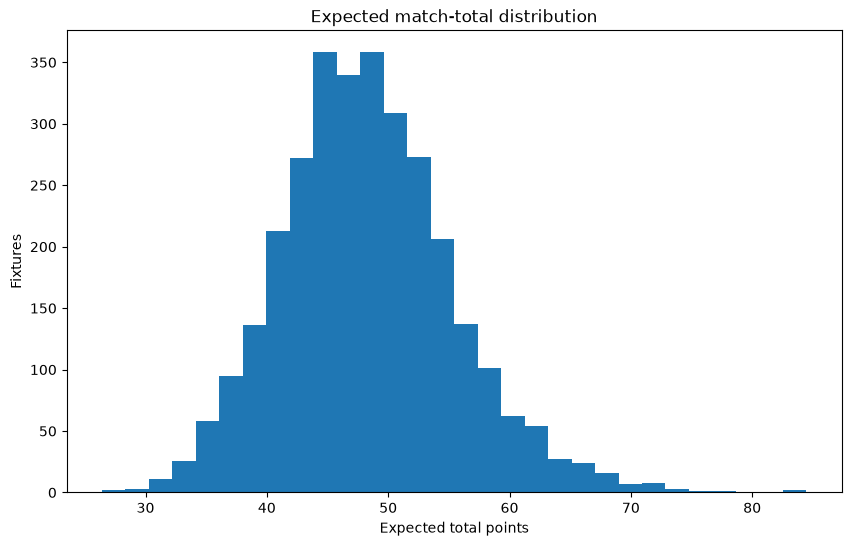

In [9]:
figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(inspection["expected_total"].dropna(), bins=30)
axis.set_title("Expected match-total distribution")
axis.set_xlabel("Expected total points")
axis.set_ylabel("Fixtures")
plt.show()


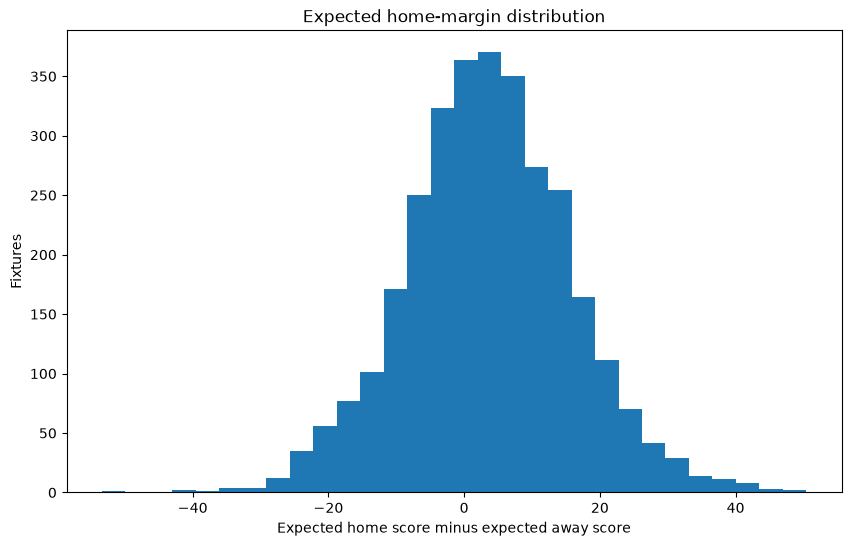

In [10]:
figure, axis = plt.subplots(figsize=(10, 6))
axis.hist(inspection["expected_margin"].dropna(), bins=30)
axis.set_title("Expected home-margin distribution")
axis.set_xlabel("Expected home score minus expected away score")
axis.set_ylabel("Fixtures")
plt.show()


## Extreme fixtures

In [21]:
preferred_columns = [
    column
    for column in [
        FIXTURE_ID_COLUMN,
        "match_date",
        "fixture_date",
        "season",
        "home_team_id",
        "away_team_id",
        HOME_EXPECTED_COLUMN,
        AWAY_EXPECTED_COLUMN,
        "expected_total",
        "expected_margin",
    ]
    if column is not None and column in inspection.columns
]

print("Highest expected totals")
display(
    inspection.sort_values("expected_total", ascending=False)[preferred_columns].head(5)
)

print("Largest expected home wins")
display(
    inspection.sort_values("expected_margin", ascending=False)[preferred_columns].head(5)
)

print("Largest expected away wins")
display(
    inspection.sort_values("expected_margin")[preferred_columns].head(5)
)


Highest expected totals


,fixture_id,match_date,season,home_team_id,away_team_id,expected_home_score,expected_away_score,expected_total,expected_margin
845,2014-02-16_14_6,2014-02-16,2014,14,6,49.980,34.485,84.465,15.495
1797,2019-02-03_19_8,2019-02-03,2019,19,8,34.852,48.108,82.960,-13.256
386,2011-08-14_12_8,2011-08-14,2011,12,8,63.626,13.195,76.821,50.431
1096,2015-04-02_8_3,2015-04-02,2015,8,3,30.267,44.588,74.855,-14.321
1802,2019-02-10_10_19,2019-02-10,2019,10,19,50.464,23.314,73.779,27.150


Largest expected home wins


,fixture_id,match_date,season,home_team_id,away_team_id,expected_home_score,expected_away_score,expected_total,expected_margin
386,2011-08-14_12_8,2011-08-14,2011,12,8,63.626,13.195,76.821,50.431
2582,2023-09-15_1_6,2023-09-15,2023,1,6,59.609,9.483,69.092,50.126
3023,2026-04-30_5_6,2026-04-30,2026,5,6,56.879,10.239,67.118,46.639
2936,2025-09-12_1_6,2025-09-12,2025,1,6,55.102,9.067,64.169,46.035
2814,2025-03-30_1_10,2025-03-30,2025,1,10,57.999,12.373,70.372,45.625


Largest expected away wins


,fixture_id,match_date,season,home_team_id,away_team_id,expected_home_score,expected_away_score,expected_total,expected_margin
2784,2025-02-21_4_1,2025-02-21,2025,4,1,7.419,60.802,68.221,-53.383
2603,2024-02-17_6_1,2024-02-17,2024,6,1,10.303,52.813,63.115,-42.510
2858,2025-05-30_10_1,2025-05-30,2025,10,1,12.978,54.415,67.393,-41.437
2691,2024-06-16_19_9,2024-06-16,2024,19,9,14.546,53.121,67.668,-38.575
2786,2025-02-22_6_9,2025-02-22,2025,6,9,16.304,51.086,67.391,-34.782


## Join fixture and team names

In [13]:
enriched_scores = inspection.copy()

with sqlite3.connect(DATABASE_PATH) as connection:
    available_tables = set(
        pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type = 'table'",
            connection,
        )["name"]
    )

    team_name_column = None
    if "teams" in available_tables:
        team_columns = set(
            pd.read_sql_query("PRAGMA table_info(teams)", connection)["name"]
        )
        for candidate in ["team_name", "canonical_name", "name"]:
            if candidate in team_columns:
                team_name_column = candidate
                break

    if {"fixtures", "teams"}.issubset(available_tables) and FIXTURE_ID_COLUMN and team_name_column:
        fixture_details = pd.read_sql_query(
            f'''
            SELECT
                f.fixture_id,
                f.match_date,
                f.season,
                f.home_team_id,
                home.{team_name_column} AS home_team,
                f.away_team_id,
                away.{team_name_column} AS away_team
            FROM fixtures AS f
            LEFT JOIN teams AS home ON home.team_id = f.home_team_id
            LEFT JOIN teams AS away ON away.team_id = f.away_team_id
            ''',
            connection,
        )

        enriched_scores = inspection.merge(
            fixture_details,
            left_on=FIXTURE_ID_COLUMN,
            right_on="fixture_id",
            how="left",
            suffixes=("", "_fixture"),
        )
    else:
        print(
            "Could not enrich with team names. Check fixtures/teams tables, fixture id column, and team name columns."
        )

display(enriched_scores.head())


,expected_score_id,fixture_id,match_date,season,home_team_id,away_team_id,league_average_points,home_scoring_factor,away_scoring_factor,home_attack_multiplier,home_defence_multiplier,away_attack_multiplier,away_defence_multiplier,expected_home_score,expected_away_score,expected_margin,expected_total,created_at,updated_at,match_date_fixture,season_fixture,home_team_id_fixture,home_team,away_team_id_fixture,away_team
0,1,2010-01-30_17_8,2010-01-30,2010,17,8,20.000,0.300,1.700,1.000,1.000,1.000,1.000,6.000,34.000,-28.000,40.000,2026-07-29 14:44:07,2026-07-29 14:44:07,2010-01-30,2010,17,Harlequins RL,8,Wakefield Trinity
1,2,2010-02-05_11_14,2010-02-05,2010,11,14,17.000,0.471,1.529,1.000,1.000,1.000,1.000,8.000,26.000,-18.000,34.000,2026-07-29 14:44:07,2026-07-29 14:44:07,2010-02-05,2010,11,Huddersfield Giants,14,Bradford Bulls
2,3,2010-02-05_1_16,2010-02-05,2010,1,16,17.000,0.471,1.529,1.000,1.000,0.837,1.240,9.923,21.750,-11.827,31.673,2026-07-29 14:44:07,2026-07-29 14:44:07,2010-02-05,2010,1,Wigan Warriors,16,Crusaders RL
3,4,2010-02-05_7_6,2010-02-05,2010,7,6,17.000,0.471,1.529,1.209,0.831,1.000,1.000,9.676,21.608,-11.932,31.284,2026-07-29 14:44:07,2026-07-29 14:44:07,2010-02-05,2010,7,Leeds Rhinos,6,Castleford Tigers
4,5,2010-02-06_9_4,2010-02-06,2010,9,4,18.200,0.967,1.033,1.000,1.000,1.000,1.000,17.600,18.800,-1.200,36.400,2026-07-29 14:44:07,2026-07-29 14:44:07,2010-02-06,2010,9,St Helens,4,Hull FC


## Team-level expected scores

In [14]:
if {"home_team", "away_team"}.issubset(enriched_scores.columns):
    home_view = enriched_scores[["home_team", HOME_EXPECTED_COLUMN]].rename(
        columns={"home_team": "team", HOME_EXPECTED_COLUMN: "expected_for"}
    )
    away_view = enriched_scores[["away_team", AWAY_EXPECTED_COLUMN]].rename(
        columns={"away_team": "team", AWAY_EXPECTED_COLUMN: "expected_for"}
    )

    team_expected_for = (
        pd.concat([home_view, away_view], ignore_index=True)
        .groupby("team", as_index=False)
        .agg(
            fixtures=("expected_for", "size"),
            mean_expected_for=("expected_for", "mean"),
            median_expected_for=("expected_for", "median"),
            maximum_expected_for=("expected_for", "max"),
        )
        .sort_values("mean_expected_for", ascending=False)
    )

    display(team_expected_for)
else:
    print("Team names were not available.")


,team,fixtures,mean_expected_for,median_expected_for,maximum_expected_for
18,Wigan Warriors,528,26.951,25.992,60.802
12,St Helens,515,26.629,25.605,53.121
16,Warrington Wolves,513,26.363,25.441,63.626
8,Leeds Rhinos,506,25.102,24.411,50.523
7,Hull Kingston Rovers,450,24.487,23.530,56.879
2,Catalans Dragons,486,23.908,22.976,56.107
1,Castleford Tigers,481,23.781,22.940,56.884
5,Huddersfield Giants,490,23.566,22.786,48.225
6,Hull FC,493,23.097,22.608,46.443
17,Widnes Vikings,198,22.793,22.324,51.506


## Compare expected and actual scores

In [15]:
comparison = None

with sqlite3.connect(DATABASE_PATH) as connection:
    if "results" in available_tables and FIXTURE_ID_COLUMN:
        actual_results = pd.read_sql_query(
            "SELECT fixture_id, home_score, away_score FROM results",
            connection,
        )

        comparison = enriched_scores.merge(
            actual_results,
            left_on=FIXTURE_ID_COLUMN,
            right_on="fixture_id",
            how="inner",
            suffixes=("", "_result"),
        )

        comparison["actual_total"] = comparison["home_score"] + comparison["away_score"]
        comparison["actual_margin"] = comparison["home_score"] - comparison["away_score"]
        comparison["home_error"] = (
            comparison["home_score"] - comparison[HOME_EXPECTED_COLUMN]
        )
        comparison["away_error"] = (
            comparison["away_score"] - comparison[AWAY_EXPECTED_COLUMN]
        )
        comparison["total_error"] = (
            comparison["actual_total"] - comparison["expected_total"]
        )
        comparison["margin_error"] = (
            comparison["actual_margin"] - comparison["expected_margin"]
        )

if comparison is None or comparison.empty:
    print("No completed results could be joined.")
else:
    metrics = pd.Series(
        {
            "home_mean_error": comparison["home_error"].mean(),
            "away_mean_error": comparison["away_error"].mean(),
            "total_mean_error": comparison["total_error"].mean(),
            "margin_mean_error": comparison["margin_error"].mean(),
            "home_mae": comparison["home_error"].abs().mean(),
            "away_mae": comparison["away_error"].abs().mean(),
            "total_mae": comparison["total_error"].abs().mean(),
            "margin_mae": comparison["margin_error"].abs().mean(),
        },
        name="value",
    )
    display(metrics.to_frame())


,value
home_mean_error,-1.259
away_mean_error,-1.446
total_mean_error,-2.705
margin_mean_error,0.186
home_mae,10.579
away_mae,9.400
total_mae,12.436
margin_mae,15.932


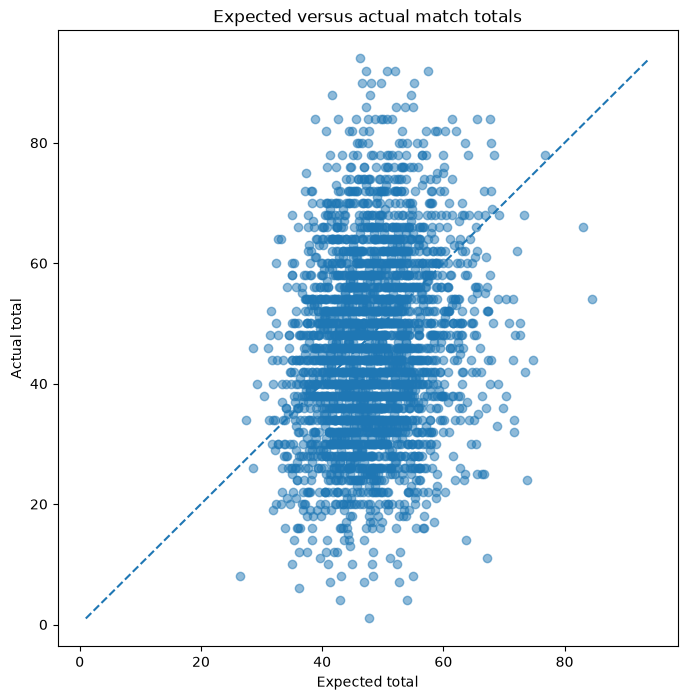

In [16]:
if comparison is not None and not comparison.empty:
    figure, axis = plt.subplots(figsize=(8, 8))
    axis.scatter(
        comparison["expected_total"],
        comparison["actual_total"],
        alpha=0.5,
    )
    lower = min(comparison["expected_total"].min(), comparison["actual_total"].min())
    upper = max(comparison["expected_total"].max(), comparison["actual_total"].max())
    axis.plot([lower, upper], [lower, upper], linestyle="--")
    axis.set_title("Expected versus actual match totals")
    axis.set_xlabel("Expected total")
    axis.set_ylabel("Actual total")
    plt.show()


## Largest model misses

In [ ]:
if comparison is not None and not comparison.empty:
    comparison["absolute_total_error"] = comparison["total_error"].abs()
    comparison["absolute_margin_error"] = comparison["margin_error"].abs()

    columns = [
        column
        for column in [
            FIXTURE_ID_COLUMN,
            "match_date",
            "season",
            "home_team",
            "away_team",
            HOME_EXPECTED_COLUMN,
            AWAY_EXPECTED_COLUMN,
            "home_score",
            "away_score",
            "expected_total",
            "actual_total",
            "total_error",
            "expected_margin",
            "actual_margin",
            "margin_error",
        ]
        if column is not None and column in comparison.columns
    ]

    print("Largest total misses")
    display(
        comparison.sort_values("absolute_total_error", ascending=False)[columns].head(5)
    )

    print("Largest margin misses")
    display(
        comparison.sort_values("absolute_margin_error", ascending=False)[columns].head(5)
    )


Largest total misses


,fixture_id,match_date,season,home_team,away_team,expected_home_score,expected_away_score,home_score,away_score,expected_total,actual_total,total_error,expected_margin,actual_margin,margin_error
1299,2016-04-15_11_12,2016-04-15,2016,Huddersfield Giants,Warrington Wolves,22.310,44.899,11,0,67.209,11,-56.209,-22.589,11,33.589
2344,2022-06-24_12_4,2022-06-24,2022,Warrington Wolves,Hull FC,22.686,31.379,4,0,54.066,4,-50.066,-8.693,4,12.693
1802,2019-02-10_10_19,2019-02-10,2019,Salford Red Devils,London Broncos,50.464,23.314,24,0,73.779,24,-49.779,27.150,24,-3.150
2700,2024-07-05_9_6,2024-07-05,2024,St Helens,Castleford Tigers,52.202,11.460,6,8,63.662,14,-49.662,40.742,-2,-42.742
836,2013-09-19_11_4,2013-09-19,2013,Huddersfield Giants,Hull FC,25.893,20.370,76,18,46.263,94,47.737,5.524,58,52.476
2158,2021-06-17_9_12,2021-06-17,2021,St Helens,Warrington Wolves,31.430,23.532,2,6,54.962,8,-46.962,7.898,-4,-11.898
2776,2025-02-13_1_2,2025-02-13,2025,Wigan Warriors,Leigh Leopards,39.909,7.740,0,1,47.649,1,-46.649,32.169,-1,-33.169
248,2011-03-20_12_17,2011-03-20,2011,Warrington Wolves,Harlequins RL,22.592,19.072,82,6,41.664,88,46.336,3.520,76,72.480
879,2014-03-23_4_18,2014-03-23,2014,Hull FC,Widnes Vikings,27.773,24.933,0,7,52.707,7,-45.707,2.840,-7,-9.840
86,2010-05-01_10_12,2010-05-01,2010,Salford Red Devils,Warrington Wolves,13.967,24.899,16,68,38.865,84,45.135,-10.932,-52,-41.068


Largest margin misses


,fixture_id,match_date,season,home_team,away_team,expected_home_score,expected_away_score,home_score,away_score,expected_total,actual_total,total_error,expected_margin,actual_margin,margin_error
248,2011-03-20_12_17,2011-03-20,2011,Warrington Wolves,Harlequins RL,22.592,19.072,82,6,41.664,88,46.336,3.520,76,72.480
609,2012-09-01_14_4,2012-09-01,2012,Bradford Bulls,Hull FC,29.650,22.262,6,70,51.911,76,24.089,7.388,-64,-71.388
2780,2025-02-15_9_10,2025-02-15,2025,St Helens,Salford Red Devils,28.898,15.953,82,0,44.852,82,37.148,12.945,82,69.055
828,2013-09-07_14_11,2013-09-07,2013,Bradford Bulls,Huddersfield Giants,18.010,34.784,58,6,52.795,64,11.205,-16.774,52,68.774
695,2013-04-01_5_1,2013-04-01,2013,Hull Kingston Rovers,Wigan Warriors,19.225,28.818,6,84,48.042,90,41.958,-9.593,-78,-68.407
1297,2016-04-10_8_1,2016-04-10,2016,Wakefield Trinity,Wigan Warriors,16.777,21.435,62,0,38.212,62,23.788,-4.659,62,66.659
1505,2017-05-20_4_9,2017-05-20,2017,Hull FC,St Helens,35.007,14.071,0,45,49.078,45,-4.078,20.936,-45,-65.936
2023,2020-08-09_7_9,2020-08-09,2020,Leeds Rhinos,St Helens,33.075,17.253,0,48,50.328,48,-2.328,15.822,-48,-63.822
1107,2015-04-11_12_8,2015-04-11,2015,Warrington Wolves,Wakefield Trinity,35.574,17.645,80,0,53.220,80,26.780,17.929,80,62.071
2988,2026-03-21_12_6,2026-03-21,2026,Warrington Wolves,Castleford Tigers,26.480,21.611,72,6,48.091,78,29.909,4.869,66,61.131


## Optional filters

In [18]:
# Examples:
# display(enriched_scores.query("season == 2026").sort_values("expected_total", ascending=False).head(50))
# display(enriched_scores.query("home_team == 'Wigan Warriors' or away_team == 'Wigan Warriors'").head(50))
# display(enriched_scores.query("expected_total >= 55").sort_values("expected_total", ascending=False))


In [20]:
query = """
SELECT
    e.fixture_id,
    f.match_date,
    ht.team_name AS home_team,
    at.team_name AS away_team,

    e.expected_home_score,
    e.expected_away_score,

    r.home_score,
    r.away_score

FROM expected_scores e

JOIN fixtures f
    ON e.fixture_id = f.fixture_id

JOIN results r
    ON e.fixture_id = r.fixture_id

JOIN teams ht
    ON f.home_team_id = ht.team_id

JOIN teams at
    ON f.away_team_id = at.team_id

ORDER BY f.match_date
"""

comparison = pd.read_sql(query, connection)

comparison.head()

DatabaseError: Execution failed on sql '
SELECT
    e.fixture_id,
    f.match_date,
    ht.team_name AS home_team,
    at.team_name AS away_team,

    e.expected_home_score,
    e.expected_away_score,

    r.home_score,
    r.away_score

FROM expected_scores e

JOIN fixtures f
    ON e.fixture_id = f.fixture_id

JOIN results r
    ON e.fixture_id = r.fixture_id

JOIN teams ht
    ON f.home_team_id = ht.team_id

JOIN teams at
    ON f.away_team_id = at.team_id

ORDER BY f.match_date
': no such column: ht.team_name